# Imports

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from transformers import BertTokenizer, BertModel
import torch
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import re
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.model_selection import RepeatedStratifiedKFold
from scipy import stats
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import matthews_corrcoef
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from itertools import combinations
!pip install scikit-posthocs
import scikit_posthocs as sp
import scipy.stats as stats

# Datasets preparation

In [ ]:
df_ref = pd.read_csv("./files/df_ml_good_with_features.csv")

df_ref_amy = df_ref[df_ref['class'] == 1]
df_ref_nonamy = df_ref[df_ref['class'] == 0]

df_protgpt2 = pd.read_csv("./files/final_datasets/protgpt_final.csv")
df_cvae = pd.read_csv("./files/final_datasets/cvae_final.csv")
df_diff = pd.read_csv("./files/final_datasets/diff_final.csv")
df_gpt_af = pd.read_csv("./files/final_datasets/from_alphafold/protgpt_features_filtered.csv")
df_cvae_af = pd.read_csv("./files/final_datasets/from_alphafold/cvae_features_filtered.csv")
df_diff_af = pd.read_csv("./files/final_datasets/from_alphafold/diff_features_filtered.csv")

In [ ]:
selected_features = ['beta_propensity', 'proline_fraction', 'AAT', 'net_charge', 'TA', 'polar_fraction', 'a3vSA']

In [ ]:
def plot_scenario_A(df_ref, df_ref_nonamy, feature_cols, filename="scenario_A.svg"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    temp_ref = df_ref[feature_cols].copy()
    temp_ref["Class"] = "Realne Amyloidy"
    temp_non = df_ref_nonamy[feature_cols].copy()
    temp_non["Class"] = "Nie-amyloidy"
    df_plot = pd.concat([temp_ref, temp_non]).dropna()

    X_scaled = StandardScaler().fit_transform(df_plot[feature_cols])

    pca_res = PCA(n_components=2).fit_transform(X_scaled)
    tsne_res = TSNE(
        n_components=2, random_state=42, init="pca", learning_rate="auto"
    ).fit_transform(X_scaled)

    palette = {"Realne Amyloidy": "#2ecc71", "Nie-amyloidy": "#95a5a6"}

    #PCA
    sns.scatterplot(x=pca_res[:,0], y=pca_res[:,1], hue=df_plot["Class"], ax=axes[0], palette=palette, alpha=0.5, s=30)
    axes[0].set_title("Scenariusz A: Realne Amyloidy vs Nie-amyloidy (PCA)", fontsize=20)
    axes[0].set_xlabel("PC1", fontsize=18)
    axes[0].set_ylabel("PC2", fontsize=18)
    leg = axes[0].get_legend()
    if leg:
        leg.set_title(None)
        for text in leg.get_texts():
            text.set_fontsize(16)

    # t-SNE
    sns.scatterplot(x=tsne_res[:,0], y=tsne_res[:,1], hue=df_plot["Class"], ax=axes[1], palette=palette, alpha=0.5, s=30)
    axes[1].set_title("Scenariusz A: Realne Amyloidy vs Nie-amyloidy (t-SNE)", fontsize=20)
    axes[1].set_xlabel("t-SNE 1", fontsize=18)
    axes[1].set_ylabel("t-SNE 2", fontsize=18)
    leg = axes[1].get_legend()
    if leg:
        leg.set_title(None)
        for text in leg.get_texts():
            text.set_fontsize(16)

    plt.tight_layout()
    plt.savefig(filename, format="png", bbox_inches="tight")
    plt.show()

In [ ]:
plot_scenario_A(df_ref, df_ref_nonamy, selected_features, "./files/plots/scenario_A.png")

In [ ]:
scenarios = [
    {
        "name": "Scenariusz B: ProtGPT2",
        "df_synth": df_protgpt2,
        "label_synth": "ProtGPT2",
        "color_synth": "#3498db"
    },
    {
        "name": "Scenariusz C: cVAE",
        "df_synth": df_cvae,
        "label_synth": "cVAE",
        "color_synth": "#e74c3c"
    },
    {
        "name": "Scenariusz D: Diffusion",
        "df_synth": df_diff,
        "label_synth": "Diffusion",
        "color_synth": "#9b59b6"
    },
    {
        "name": "Scenariusz E: ProtGPT2 (pLDDT > 70)",
        "df_synth": df_gpt_af,
        "label_synth": "ProtGPT2 (pLDDT > 70)",
        "color_synth": "#85c1e9"
    },
    {
        "name": "Scenariusz F: cVAE (pLDDT > 70)",
        "df_synth": df_cvae_af,
        "label_synth": "cVAE (pLDDT > 70)",
        "color_synth": "#f1948a"
    },
    {
        "name": "Scenariusz G: Diffusion (pLDDT > 70)",
        "df_synth": df_diff_af,
        "label_synth": "Diffusion (pLDDT > 70)",
        "color_synth": "#c39bd3"
    }
]

In [ ]:
def plot_comparison(scenarios_subset, df_ref, df_ref_nonamy, feature_cols, filename):
    n = len(scenarios_subset)
    fig, axes = plt.subplots(n, 2, figsize=(16, 6 * n))

    if n == 1:
        axes = np.array([axes])

    for i, scen in enumerate(scenarios_subset):
        # syntetic vs real
        df_real_tmp = df_ref[feature_cols].copy()
        df_real_tmp["Class"] = "Amyloidy ref."

        df_synth_tmp = scen["df_synth"][feature_cols].copy()
        df_synth_tmp["Class"] = scen["label_synth"]

        df_left = pd.concat([df_real_tmp, df_synth_tmp]).dropna()
        X_scaled_left = StandardScaler().fit_transform(df_left[feature_cols])
        pca_left = PCA(n_components=2).fit_transform(X_scaled_left)

        palette_left = {"Amyloidy ref.": "#2ecc71", scen["label_synth"]: scen["color_synth"]}

        sns.scatterplot(
            x=pca_left[:,0], y=pca_left[:,1], hue=df_left["Class"],
            ax=axes[i,0], palette=palette_left, alpha=0.5, s=30
        )
        axes[i,0].set_title(f"{scen['name']}\n[Syntetyczne vs Realne]", fontsize=20)
        axes[i,0].set_xlabel("PC1", fontsize=18)
        axes[i,0].set_ylabel("PC2", fontsize=18)
        leg = axes[i,0].get_legend()
        if leg:
            leg.set_title(None)
            for text in leg.get_texts():
                text.set_fontsize(16)

        # (Real + Syntetic) vs negativ class
        df_pos_combined = pd.concat([df_ref, scen["df_synth"]])[feature_cols].copy()
        df_pos_combined["Class"] = f"Realne + {scen['label_synth']}"

        df_neg_tmp = df_ref_nonamy[feature_cols].copy()
        df_neg_tmp["Class"] = "Nie amyloidy"

        df_right = pd.concat([df_pos_combined, df_neg_tmp]).dropna()
        X_scaled_right = StandardScaler().fit_transform(df_right[feature_cols])
        pca_right = PCA(n_components=2).fit_transform(X_scaled_right)

        palette_right = {f"Realne + {scen['label_synth']}": scen["color_synth"], "Nie amyloidy": "#95a5a6"}

        sns.scatterplot(
            x=pca_right[:,0], y=pca_right[:,1], hue=df_right["Class"],
            ax=axes[i,1], palette=palette_right, alpha=0.5, s=30
        )
        axes[i,1].set_title(f"{scen['name']}\n[(Realne + Syntetyczne) vs Negatywne]", fontsize=20)
        axes[i,1].set_xlabel("PC1", fontsize=18)
        axes[i,1].set_ylabel("PC2", fontsize=18)
        leg = axes[i,1].get_legend()
        if leg:
            leg.set_title(None)
            for text in leg.get_texts():
                text.set_fontsize(16)

    plt.tight_layout()
    plt.savefig(filename, format="png", bbox_inches="tight")
    plt.show()

In [ ]:
plot_comparison(scenarios[:3], df_ref, df_ref_nonamy, selected_features, "./files/plots/scenarios_BCD.png")
plot_comparison(scenarios[3:], df_ref, df_ref_nonamy, selected_features, "./files/plots/scenarios_EFG.png")

## Train/Test spilt

In [ ]:
X_real = df_ref[selected_features]
y_real = df_ref["class"]

X_train_ref, X_test, y_train_ref, y_test = train_test_split(
    X_real, y_real,
    test_size=0.2,
    random_state=42,
    stratify=y_real
)

In [ ]:
df_protgpt2['class'] = 1
df_cvae['class'] = 1
df_diff['class'] = 1
df_gpt_af['class'] = 1
df_cvae_af['class'] = 1
df_diff_af['class'] = 1

train_datasets = {
    "Real Only": (X_train_ref, y_train_ref),
    "Real + ProtGPT2": (
        pd.concat([X_train_ref, df_protgpt2[selected_features]]),
        pd.concat([y_train_ref, df_protgpt2["class"]])
    ),
    "Real + cVAE": (
        pd.concat([X_train_ref, df_cvae[selected_features]]),
        pd.concat([y_train_ref, df_cvae["class"]])
    ),
    "Real + Diffusion": (
        pd.concat([X_train_ref, df_diff[selected_features]]),
        pd.concat([y_train_ref, df_diff["class"]])
    ),
    "Real + ProtGPT2 pLDDT > 70": (
        pd.concat([X_train_ref, df_gpt_af[selected_features]]),
        pd.concat([y_train_ref, df_gpt_af["class"]])
    ),
    "Real + cVAE pLDDT > 70": (
        pd.concat([X_train_ref, df_cvae_af[selected_features]]),
        pd.concat([y_train_ref, df_cvae_af["class"]])
    ),
    "Real + Diffusion pLDDT > 70": (
        pd.concat([X_train_ref, df_diff_af[selected_features]]),
        pd.concat([y_train_ref, df_diff_af["class"]])
    )
}

In [ ]:
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=42
)

# Models

## Baseline

In [ ]:
models = {
    "RandomForest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    )
}

In [ ]:
param_grids = {
    "RandomForest": {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    },
    "XGBoost": {
        'n_estimators': [100, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 6],
        'subsample': [0.8, 1.0]
    },
    "LogisticRegression": {
        'C': [0.01, 0.1, 1.0, 10.0],
        'solver': ['lbfgs', 'liblinear'], # liblinear should be good for small datasets
        'penalty': ['l2']
    }
}

In [ ]:
results_stat = []

for data_name, (X_train_curr, y_train_curr) in train_datasets.items():
    print("\n" + "=" * 80)
    print(f">>> Eksperyment for set: {data_name}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_curr)
    # test always the same
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        current_model_base_results = []
        print(f"Przetwarzanie {model_name}...")

        # looking for best params only once
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grids[model_name],
            scoring='f1',
            cv=3,
            n_jobs=-1
        )
        grid_search.fit(X_train_scaled, y_train_curr)
        best_params = grid_search.best_params_
        print(f"Best parameters: {best_params}")

        fold_idx = 0
        for train_idx, val_idx in cv.split(X_train_scaled, y_train_curr):
            X_fold_train = X_train_scaled[train_idx]
            y_fold_train = y_train_curr.iloc[train_idx]

            m = model.set_params(**best_params)
            m.fit(X_fold_train, y_fold_train)

            probs = m.predict_proba(X_test_scaled)[:, 1]
            preds = m.predict(X_test_scaled)

            row = {
                "Model": model_name,
                "Dataset": data_name,
                "Fold_ID": fold_idx,
                "AUC": roc_auc_score(y_test, probs),
                "F1": f1_score(y_test, preds),
                "ACC": accuracy_score(y_test, preds),
                "Precision": precision_score(y_test, preds, zero_division=0),
                "Recall": recall_score(y_test, preds),
                "MCC": matthews_corrcoef(y_test, preds)
            }
            fold_idx += 1
            results_stat.append(row)
            current_model_base_results.append(row)

        safe_data_name = data_name.replace(" ", "_").replace("+", "and").replace(">", "gt")
        df_temp_base = pd.DataFrame(current_model_base_results)
        filename_base = f"./files/statistics_tests/folds_dl_{model_name}_{safe_data_name}.csv"
        df_temp_base.to_csv(filename_base, index=False)

df_stat = pd.DataFrame(results_stat)
df_stat.to_csv("./files/statistics_tests/all_folds_base_final.csv", index=False)


>>> Eksperyment dla zbioru: Real Only
Przetwarzanie RandomForest...
Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 500}
Przetwarzanie XGBoost...
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Przetwarzanie LogisticRegression...
Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

>>> Eksperyment dla zbioru: Real + ProtGPT2
Przetwarzanie RandomForest...
Best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Przetwarzanie XGBoost...
Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Przetwarzanie LogisticRegression...
Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}

>>> Eksperyment dla zbioru: Real + cVAE
Przetwarzanie RandomForest...
Best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 500}
Przetwarzanie XGBoost...
Best parameters: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators'

In [ ]:
metrics = ['AUC', 'F1', 'ACC', 'Precision', 'Recall', 'MCC']

summary_table = df_stat.groupby(['Model', 'Dataset'])[metrics].agg(['mean', 'std'])
pd.options.display.float_format = '{:,.3f}'.format
summary_table.to_csv("./files/statistics_tests/full_results_baseline.csv")
print(summary_table)

                                                 AUC          F1         ACC  \
                                                mean   std  mean   std  mean   
Model              Dataset                                                     
LogisticRegression Real + Diffusion            0.733 0.003 0.697 0.006 0.669   
                   Real + Diffusion pLDDT > 70 0.738 0.002 0.730 0.005 0.695   
                   Real + ProtGPT2             0.727 0.005 0.652 0.009 0.654   
                   Real + ProtGPT2 pLDDT > 70  0.736 0.004 0.703 0.008 0.670   
                   Real + cVAE                 0.724 0.003 0.710 0.005 0.669   
                   Real + cVAE pLDDT > 70      0.744 0.001 0.739 0.006 0.695   
                   Real Only                   0.745 0.002 0.715 0.006 0.686   
RandomForest       Real + Diffusion            0.732 0.006 0.737 0.004 0.660   
                   Real + Diffusion pLDDT > 70 0.770 0.006 0.754 0.009 0.706   
                   Real + ProtGPT2      

In [ ]:
def plot_results(df, models, metric='F1'):
    plt.figure(figsize=(14, 8))

    sns.boxplot(data=df, x='Model', y=metric, hue='Dataset')

    plt.title(f'Porównanie modeli: {metric}', fontsize=20)
    plt.xlabel('Model', fontsize=16)
    plt.ylabel(metric, fontsize=16)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        fontsize=14,
        title_fontsize=15
    )

    plt.tight_layout()
    plt.savefig(f'./files/plots/boxplot_{models}_{metric}.svg', format="svg")

    plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

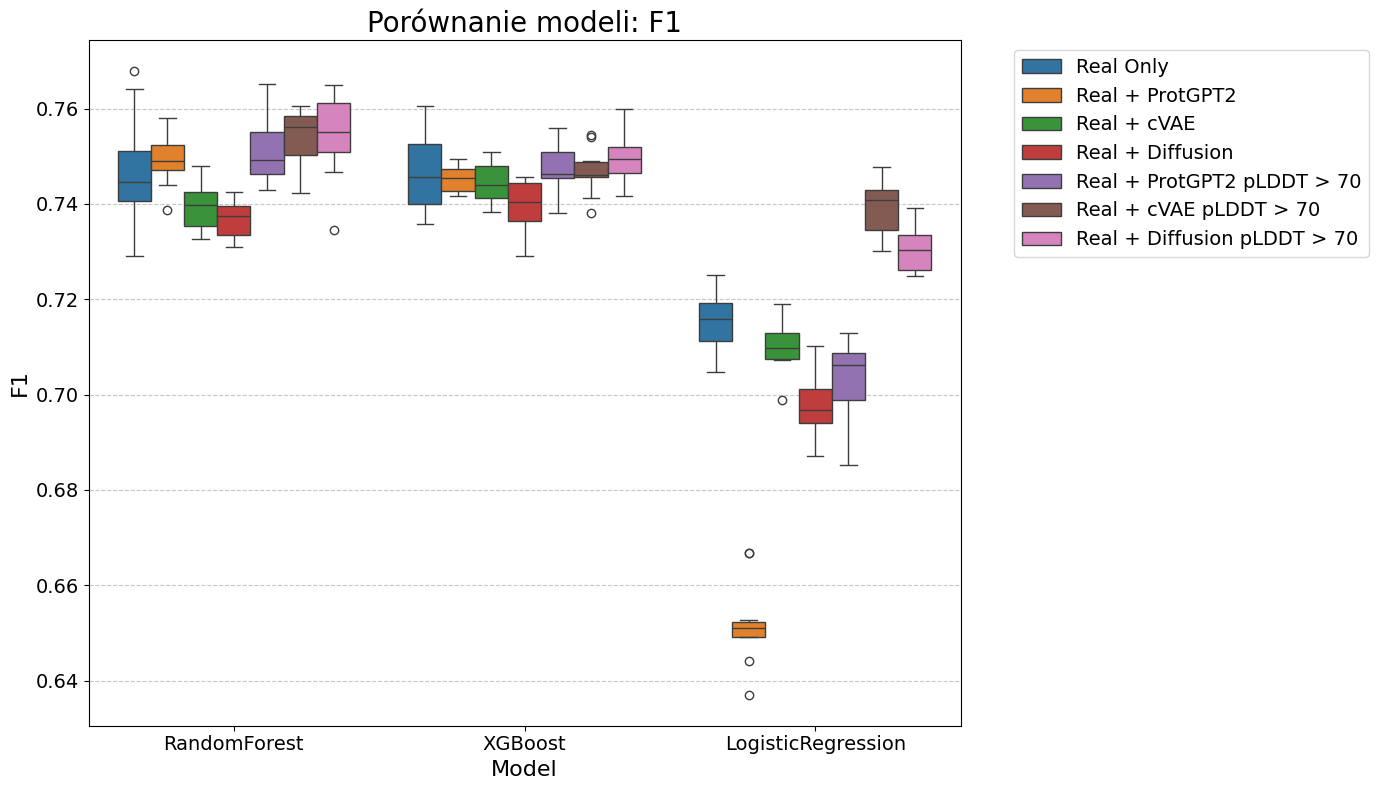

In [ ]:
plot_results(df_stat, "baseline")

## Deep models

MLP

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1) # BCEWithLogitsLoss
        )

    def forward(self, x):
        return self.net(x)

CNNHybrid

In [ ]:
class CNNHybrid(nn.Module):
    def __init__(self, vocab_size, feat_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32, padding_idx=0)
        self.conv = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1)
        )
        self.feat_net = nn.Sequential(
            nn.Linear(feat_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 + 32, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 1)
        )

    def forward(self, seq, feats):
        x = self.embedding(seq).permute(0, 2, 1)
        x = self.conv(x).squeeze(-1)
        f = self.feat_net(feats)
        combined = torch.cat([x, f], dim=1)
        return self.classifier(combined)

ProtBERT MLP

In [ ]:
class ProtBERT_MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x, _=None):
        return self.net(x)

In [ ]:
def preprocess_sequence(seq):
    seq = seq.upper()
    seq = re.sub(r"[UZOB]", "X", seq)
    return " ".join(list(seq))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
model_bert = BertModel.from_pretrained("Rostlab/prot_bert").to(device)

def get_embeddings(sequences, batch_size=16):
    embeddings = []

    for i in tqdm(range(0, len(sequences), batch_size)):
        batch_seqs = sequences[i:i+batch_size]
        batch_seqs = [preprocess_sequence(seq) for seq in batch_seqs]

        encoded = tokenizer(batch_seqs,
                            return_tensors="pt",
                            padding=True,
                            truncation=True,
                            max_length=512)

        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)

        with torch.no_grad():
            outputs = model_bert(input_ids=input_ids,
                                 attention_mask=attention_mask)

        # (batch, seq_len, hidden_dim)
        hidden_states = outputs.last_hidden_state

        # mean pooling (ignorujemy padding)
        mask = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
        summed = torch.sum(hidden_states * mask, dim=1)
        counts = torch.clamp(mask.sum(dim=1), min=1e-9)
        mean_pooled = summed / counts

        embeddings.append(mean_pooled.cpu().numpy())

    return np.vstack(embeddings)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/361 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Training

In [ ]:
def run_deep_experiment(model, train_loader, val_loader, device, lr=0.001, patience=12):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5) # L2 Regularization

    best_loss = float('inf')
    best_state = None
    counter = 0

    for epoch in range(200):
        # Training
        model.train()
        train_loss = 0
        for seq, feat, labels in train_loader:
            seq, feat, labels = seq.to(device), feat.to(device), labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            logits = model(seq, feat) if not isinstance(model, MLP) and not isinstance(model, ProtBERT_MLP) else model(feat)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for seq, feat, labels in val_loader:
                seq, feat, labels = seq.to(device), feat.to(device), labels.to(device).unsqueeze(1)
                logits = model(seq, feat) if not isinstance(model, MLP) and not isinstance(model, ProtBERT_MLP) else model(feat)
                val_loss += criterion(logits, labels).item()

        avg_val_loss = val_loss / len(val_loader)

        # Early Stopping check
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_state = model.state_dict()
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            break

    model.load_state_dict(best_state)
    return model

In [ ]:
class AmyloidDataset(Dataset):
    def __init__(self, sequences, features, labels, aa_to_idx, max_len=50):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels.values if hasattr(labels, 'values') else labels, dtype=torch.float32)
        self.sequences = [self._encode(s, aa_to_idx, max_len) for s in sequences]

    def _encode(self, seq, aa_to_idx, max_len):
        encoded = [aa_to_idx.get(aa, 0) for aa in str(seq)[:max_len]]
        padding = [0] * (max_len - len(encoded))
        return torch.tensor(encoded + padding, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.features[idx], self.labels[idx]

amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
aa_to_idx = {aa: i+1 for i, aa in enumerate(amino_acids)}

In [ ]:
print("Generowanie embeddingów ProtBERT dla zbioru testowego...")
X_test_embed = get_embeddings(df_ref.loc[X_test.index, "sequence"].tolist())
X_test_scaled_features = StandardScaler().fit_transform(X_test)
X_test_combined_bert = np.concatenate([X_test_embed, X_test_scaled_features], axis=1)

# for ProtBERT (Test)
test_ds_bert = AmyloidDataset(df_ref.loc[X_test.index, "sequence"], X_test_combined_bert, y_test, aa_to_idx)
test_loader_bert_final = DataLoader(test_ds_bert, batch_size=64, shuffle=False)

# for MLP/CNN (Test)
test_ds_standard = AmyloidDataset(df_ref.loc[X_test.index, "sequence"], X_test_scaled_features, y_test, aa_to_idx)
test_loader_standard = DataLoader(test_ds_standard, batch_size=64, shuffle=False)

Generowanie embeddingów ProtBERT dla zbioru testowego...



100%|██████████| 25/25 [00:05<00:00,  4.98it/s]


In [ ]:
n_splits = 5
n_repeats = 2
cv_outer = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

results_dl = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for data_name, (X_train_curr, y_train_curr) in train_datasets.items():
    print(f"\n" + "="*50)
    print(f"START REPEATED K-FOLD DL: {data_name}")
    print("="*50)

    if data_name == "Real Only":
        current_seqs = df_ref.loc[X_train_curr.index, "sequence"]
    elif "ProtGPT2 pLDDT" in data_name:
        current_seqs = pd.concat([df_ref.loc[X_train_ref.index, "sequence"], df_gpt_af["sequence"]])
    elif "cVAE pLDDT" in data_name:
        current_seqs = pd.concat([df_ref.loc[X_train_ref.index, "sequence"], df_cvae_af["sequence"]])
    elif "Diffusion pLDDT" in data_name:
        current_seqs = pd.concat([df_ref.loc[X_train_ref.index, "sequence"], df_diff_af["sequence"]])
    elif "ProtGPT2" in data_name:
        current_seqs = pd.concat([df_ref.loc[X_train_ref.index, "sequence"], df_protgpt2["sequence"]])
    elif "cVAE" in data_name:
        current_seqs = pd.concat([df_ref.loc[X_train_ref.index, "sequence"], df_cvae["sequence"]])
    elif "Diffusion" in data_name:
        current_seqs = pd.concat([df_ref.loc[X_train_ref.index, "sequence"], df_diff["sequence"]])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_curr)
    y_train_arr = y_train_curr.values if hasattr(y_train_curr, 'values') else np.array(y_train_curr)

    print(f"[{data_name}] Generowanie wektorów ProtBERT...")
    X_embed_all = get_embeddings(current_seqs.tolist())
    X_combined_bert_all = np.concatenate([X_embed_all, X_train_scaled], axis=1)

    model_names = ["MLP", "CNN-Hybrid", "ProtBERT-MLP"]

    for m_name in model_names:
        current_model_dl_results = []
        print(f"\n>>> Model: {m_name}")

        for fold_idx, (train_idx, val_idx) in enumerate(cv_outer.split(X_train_scaled, y_train_arr)):
            print(f"    Fold {fold_idx + 1}/{n_splits * n_repeats}...", end=" ")

            torch.manual_seed(fold_idx + 42)

            if m_name == "ProtBERT-MLP":
                tr_ds = AmyloidDataset(current_seqs.iloc[train_idx], X_combined_bert_all[train_idx], y_train_arr[train_idx], aa_to_idx)
                vl_ds = AmyloidDataset(current_seqs.iloc[val_idx], X_combined_bert_all[val_idx], y_train_arr[val_idx], aa_to_idx)
                curr_test_loader = test_loader_bert_final
                model_obj = ProtBERT_MLP(input_dim=1024 + len(selected_features))
            else:
                tr_ds = AmyloidDataset(current_seqs.iloc[train_idx], X_train_scaled[train_idx], y_train_arr[train_idx], aa_to_idx)
                vl_ds = AmyloidDataset(current_seqs.iloc[val_idx], X_train_scaled[val_idx], y_train_arr[val_idx], aa_to_idx)
                curr_test_loader = test_loader_standard
                if m_name == "MLP":
                    model_obj = MLP(input_dim=len(selected_features))
                else:
                    model_obj = CNNHybrid(vocab_size=len(amino_acids)+1, feat_dim=len(selected_features))

            train_loader = DataLoader(tr_ds, batch_size=32, shuffle=True)
            val_loader = DataLoader(vl_ds, batch_size=64, shuffle=False)

            trained_model = run_deep_experiment(model_obj, train_loader, val_loader, device)

            trained_model.eval()
            all_probs, all_labels = [], []
            with torch.no_grad():
                for s_t, f_t, l_t in curr_test_loader:
                    s_t, f_t = s_t.to(device), f_t.to(device)
                    logits = trained_model(f_t) if m_name in ["MLP", "ProtBERT-MLP"] else trained_model(s_t, f_t)
                    probs = torch.sigmoid(logits).cpu().numpy().flatten()
                    all_probs.extend(probs)
                    all_labels.extend(l_t.numpy())

            all_probs = np.array(all_probs)
            all_preds = (all_probs > 0.5).astype(int)

            f1 = f1_score(all_labels, all_preds)
            print(f"F1: {f1:.4f}")

            row = {
                "Dataset": data_name,
                "Model": m_name,
                "Fold_ID": fold_idx,
                "AUC": roc_auc_score(all_labels, all_probs),
                "F1": f1,
                "ACC": accuracy_score(all_labels, all_preds),
                "Precision": precision_score(all_labels, all_preds),
                "Recall": recall_score(all_labels, all_preds),
                "MCC": matthews_corrcoef(all_labels, all_preds)
            }
            results_dl.append(row)
            current_model_dl_results.append(row)

        safe_data_name = data_name.replace(" ", "_").replace("+", "and").replace(">", "gt")
        df_temp_dl = pd.DataFrame(current_model_dl_results)
        filename_dl = f"folds_dl_{m_name}_{safe_data_name}.csv"
        df_temp_dl.to_csv(filename_dl, index=False)

df_stat_dl = pd.DataFrame(results_dl)
df_stat_dl.to_csv("all_folds_dl_final.csv", index=False)

df_stat_dl = pd.DataFrame(results_dl)


START REPEATED K-FOLD DL: Real Only
[Real Only] Generowanie wektorów ProtBERT...


100%|██████████| 97/97 [00:16<00:00,  5.97it/s]



>>> Model: MLP
    Fold 1/10... F1: 0.7139
    Fold 2/10... F1: 0.7268
    Fold 3/10... F1: 0.7076
    Fold 4/10... F1: 0.7210
    Fold 5/10... F1: 0.7237
    Fold 6/10... F1: 0.7053
    Fold 7/10... F1: 0.7097
    Fold 8/10... F1: 0.7178
    Fold 9/10... F1: 0.7268
    Fold 10/10... F1: 0.7308

>>> Model: CNN-Hybrid
    Fold 1/10... F1: 0.8182
    Fold 2/10... F1: 0.7787
    Fold 3/10... F1: 0.7781
    Fold 4/10... F1: 0.7970
    Fold 5/10... F1: 0.7877
    Fold 6/10... F1: 0.7902
    Fold 7/10... F1: 0.8040
    Fold 8/10... F1: 0.8010
    Fold 9/10... F1: 0.6209
    Fold 10/10... F1: 0.8396

>>> Model: ProtBERT-MLP
    Fold 1/10... F1: 0.8010
    Fold 2/10... F1: 0.7971
    Fold 3/10... F1: 0.7896
    Fold 4/10... F1: 0.8065
    Fold 5/10... F1: 0.7891
    Fold 6/10... F1: 0.7909
    Fold 7/10... F1: 0.7592
    Fold 8/10... F1: 0.8027
    Fold 9/10... F1: 0.7925
    Fold 10/10... F1: 0.7898

START REPEATED K-FOLD DL: Real + ProtGPT2
[Real + ProtGPT2] Generowanie wektorów ProtBERT...

100%|██████████| 881/881 [02:24<00:00,  6.09it/s]



>>> Model: MLP
    Fold 1/10... F1: 0.6970
    Fold 2/10... F1: 0.6944
    Fold 3/10... F1: 0.6946
    Fold 4/10... F1: 0.6969
    Fold 5/10... F1: 0.6982
    Fold 6/10... F1: 0.6944
    Fold 7/10... F1: 0.7005
    Fold 8/10... F1: 0.6960
    Fold 9/10... F1: 0.6981
    Fold 10/10... F1: 0.7018

>>> Model: CNN-Hybrid
    Fold 1/10... F1: 0.8096
    Fold 2/10... F1: 0.8019
    Fold 3/10... F1: 0.8232
    Fold 4/10... F1: 0.8136
    Fold 5/10... F1: 0.8257
    Fold 6/10... F1: 0.8045
    Fold 7/10... F1: 0.8134
    Fold 8/10... F1: 0.7916
    Fold 9/10... F1: 0.8070
    Fold 10/10... F1: 0.8188

>>> Model: ProtBERT-MLP
    Fold 1/10... F1: 0.7551
    Fold 2/10... F1: 0.7465
    Fold 3/10... F1: 0.7566
    Fold 4/10... F1: 0.7404
    Fold 5/10... F1: 0.7297
    Fold 6/10... F1: 0.7423
    Fold 7/10... F1: 0.7435
    Fold 8/10... F1: 0.7516
    Fold 9/10... F1: 0.7495
    Fold 10/10... F1: 0.7521

START REPEATED K-FOLD DL: Real + cVAE
[Real + cVAE] Generowanie wektorów ProtBERT...


...


>>> Model: MLP
    Fold 1/10... F1: 0.7313
    Fold 2/10... F1: 0.7544
    Fold 3/10... F1: 0.7435
    Fold 4/10... F1: 0.7440
    Fold 5/10... F1: 0.7389
    Fold 6/10... F1: 0.7293
    Fold 7/10... F1: 0.7391
    Fold 8/10... F1: 0.7345
    Fold 9/10... F1: 0.7417
    Fold 10/10... F1: 0.7289

>>> Model: CNN-Hybrid
    Fold 1/10... F1: 0.7861
    Fold 2/10... F1: 0.7596
    Fold 3/10... F1: 0.8213
    Fold 4/10... F1: 0.8109
    Fold 5/10... F1: 0.8125
    Fold 6/10... F1: 0.8257
    Fold 7/10... F1: 0.7909
    Fold 8/10... F1: 0.8170
    Fold 9/10... F1: 0.8192
    Fold 10/10... F1: 0.8134

>>> Model: ProtBERT-MLP
    Fold 1/10... F1: 0.7849
    Fold 2/10... F1: 0.8020
    Fold 3/10... F1: 0.8009
    Fold 4/10... F1: 0.7890
    Fold 5/10... F1: 0.7871
    Fold 6/10... F1: 0.7897
    Fold 7/10... F1: 0.7935
    Fold 8/10... F1: 0.7850
    Fold 9/10... F1: 0.7887
    Fold 10/10... F1: 0.7891

START REPEATED K-FOLD DL: Real + cVAE pLDDT > 70
[Real + cVAE pLDDT > 70] Generowanie wektor

100%|██████████| 150/150 [00:18<00:00,  8.29it/s]



>>> Model: MLP
    Fold 1/10... F1: 0.7692
    Fold 2/10... F1: 0.7623
    Fold 3/10... F1: 0.7636
    Fold 4/10... F1: 0.7611
    Fold 5/10... F1: 0.7572
    Fold 6/10... F1: 0.7556
    Fold 7/10... F1: 0.7611
    Fold 8/10... F1: 0.7653
    Fold 9/10... F1: 0.7564
    Fold 10/10... F1: 0.7610

>>> Model: CNN-Hybrid
    Fold 1/10... F1: 0.7940
    Fold 2/10... F1: 0.8122
    Fold 3/10... F1: 0.7924
    Fold 4/10... F1: 0.7990
    Fold 5/10... F1: 0.7782
    Fold 6/10... F1: 0.7942
    Fold 7/10... F1: 0.8213
    Fold 8/10... F1: 0.8044
    Fold 9/10... F1: 0.8252
    Fold 10/10... F1: 0.8068

>>> Model: ProtBERT-MLP
    Fold 1/10... F1: 0.7842
    Fold 2/10... F1: 0.7748
    Fold 3/10... F1: 0.8000
    Fold 4/10... F1: 0.7850
    Fold 5/10... F1: 0.7800
    Fold 6/10... F1: 0.7758
    Fold 7/10... F1: 0.7868
    Fold 8/10... F1: 0.7748
    Fold 9/10... F1: 0.8040
    Fold 10/10... F1: 0.7810

START REPEATED K-FOLD DL: Real + Diffusion pLDDT > 70
[Real + Diffusion pLDDT > 70] Generowa

100%|██████████| 138/138 [00:16<00:00,  8.30it/s]



>>> Model: MLP
    Fold 1/10... F1: 0.7453
    Fold 2/10... F1: 0.7547
    Fold 3/10... F1: 0.7364
    Fold 4/10... F1: 0.7542
    Fold 5/10... F1: 0.7495
    Fold 6/10... F1: 0.7371
    Fold 7/10... F1: 0.7495
    Fold 8/10... F1: 0.7515
    Fold 9/10... F1: 0.7449
    Fold 10/10... F1: 0.7516

>>> Model: CNN-Hybrid
    Fold 1/10... F1: 0.7692
    Fold 2/10... F1: 0.7744
    Fold 3/10... F1: 0.7685
    Fold 4/10... F1: 0.7740
    Fold 5/10... F1: 0.7950
    Fold 6/10... F1: 0.7773
    Fold 7/10... F1: 0.7885
    Fold 8/10... F1: 0.7770
    Fold 9/10... F1: 0.7719
    Fold 10/10... F1: 0.7843

>>> Model: ProtBERT-MLP
    Fold 1/10... F1: 0.7808
    Fold 2/10... F1: 0.7780
    Fold 3/10... F1: 0.7848
    Fold 4/10... F1: 0.7832
    Fold 5/10... F1: 0.8084
    Fold 6/10... F1: 0.7962
    Fold 7/10... F1: 0.7872
    Fold 8/10... F1: 0.7788
    Fold 9/10... F1: 0.7820
    Fold 10/10... F1: 0.7804


In [ ]:
metrics = ['AUC', 'F1', 'ACC', 'Precision', 'Recall', 'MCC']

summary_table = df_stat_dl.groupby(['Model', 'Dataset'])[metrics].agg(['mean', 'std'])
pd.options.display.float_format = '{:,.3f}'.format
summary_table.to_csv("final_all_results_dl.csv")
print(summary_table)

                                           AUC          F1         ACC        \
                                          mean   std  mean   std  mean   std   
Model        Dataset                                                           
CNN-Hybrid   Real + Diffusion            0.766 0.011 0.738 0.008 0.651 0.017   
             Real + Diffusion pLDDT > 70 0.837 0.012 0.778 0.009 0.755 0.019   
             Real + ProtGPT2             0.879 0.012 0.811 0.010 0.791 0.015   
             Real + ProtGPT2 pLDDT > 70  0.883 0.008 0.806 0.021 0.795 0.016   
             Real + cVAE                 0.875 0.010 0.787 0.019 0.736 0.033   
             Real + cVAE pLDDT > 70      0.879 0.013 0.803 0.014 0.782 0.023   
             Real Only                   0.879 0.010 0.782 0.059 0.788 0.034   
MLP          Real + Diffusion            0.728 0.008 0.710 0.003 0.580 0.007   
             Real + Diffusion pLDDT > 70 0.764 0.003 0.747 0.007 0.686 0.009   
             Real + ProtGPT2            

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

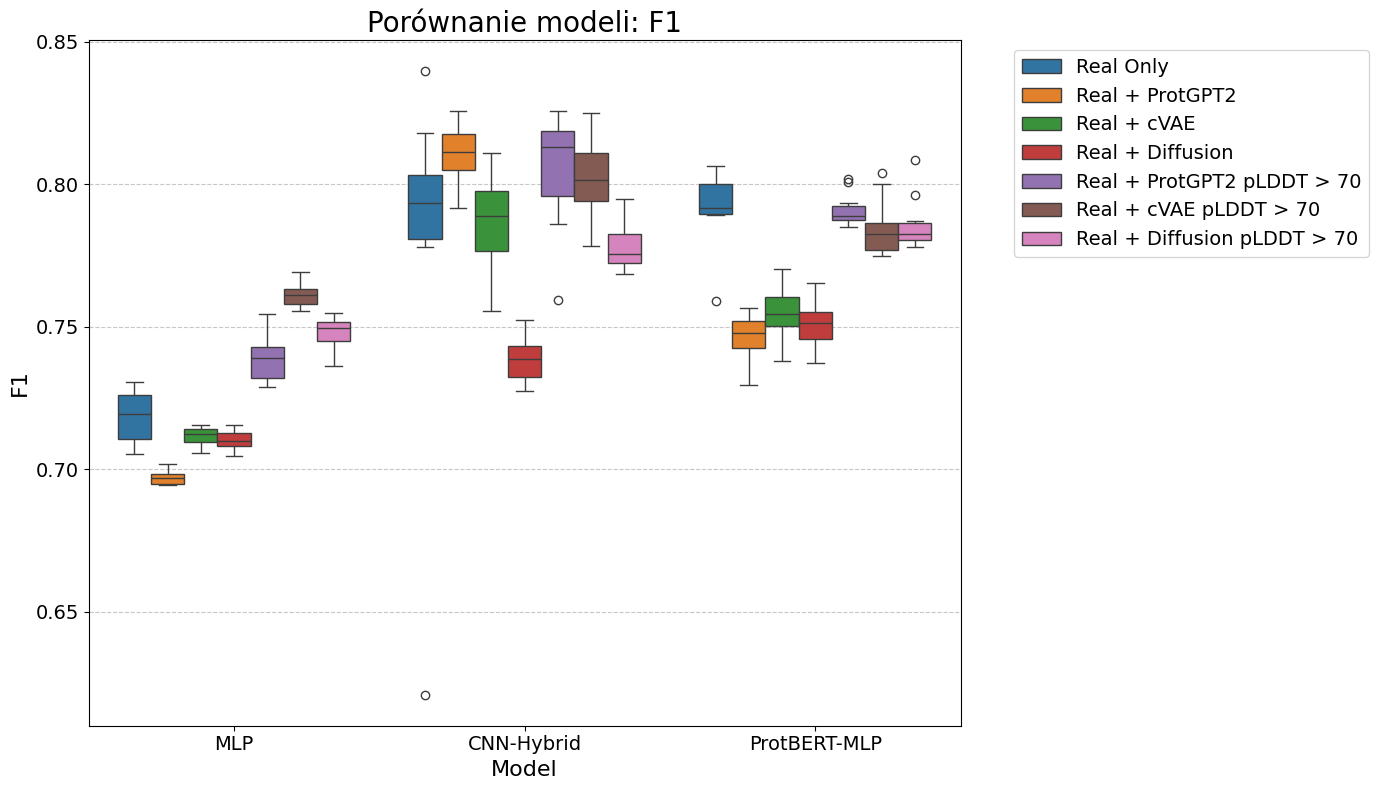

In [ ]:
plot_results(df_stat_dl, "dl")

# Control experiment: RANDOM UNDERSAMPLING

In [ ]:
# num of sequences after af2 filtration
target_counts = {
    "ProtGPT2": 579,
    "cVAE": 841,
    "Diffusion": 655
}

df_protgpt2_sampled = df_protgpt2.sample(n=target_counts["ProtGPT2"], random_state=42).reset_index(drop=True)
df_cvae_sampled = df_cvae.sample(n=target_counts["cVAE"], random_state=42).reset_index(drop=True)
df_diff_sampled = df_diff.sample(n=target_counts["Diffusion"], random_state=42).reset_index(drop=True)

In [ ]:
control_train_datasets = {
    "Real + ProtGPT2 (random undersampling)": (
        pd.concat([X_train_ref, df_protgpt2_sampled[selected_features]]),
        pd.concat([y_train_ref, df_protgpt2_sampled["class"]])
    ),
    "Real + cVAE (random undersampling)": (
        pd.concat([X_train_ref, df_cvae_sampled[selected_features]]),
        pd.concat([y_train_ref, df_cvae_sampled["class"]])
    ),
    "Real + Diffusion (random undersampling)": (
        pd.concat([X_train_ref, df_diff_sampled[selected_features]]),
        pd.concat([y_train_ref, df_diff_sampled["class"]])
    )
}

## Baseline

In [ ]:
results_control_baseline = []

for data_name, (X_train_curr, y_train_curr) in control_train_datasets.items():
    print(f"\n>>> Eksperyment baseline dla zbioru: {data_name}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_curr)
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        current_model_base_results = []
        print(f"Przetwarzanie {model_name}...")

        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grids[model_name],
            scoring='f1',
            cv=3,
            n_jobs=-1
        )
        grid_search.fit(X_train_scaled, y_train_curr)
        best_params = grid_search.best_params_

        fold_idx = 0
        for train_idx, val_idx in cv.split(X_train_scaled, y_train_curr):
            X_fold_train = X_train_scaled[train_idx]
            y_fold_train = y_train_curr.iloc[train_idx]

            m = model.set_params(**best_params)
            m.fit(X_fold_train, y_fold_train)

            probs = m.predict_proba(X_test_scaled)[:, 1]
            preds = m.predict(X_test_scaled)

            row = {
                "Model": model_name,
                "Dataset": data_name,
                "Fold_ID": fold_idx,
                "AUC": roc_auc_score(y_test, probs),
                "F1": f1_score(y_test, preds),
                "ACC": accuracy_score(y_test, preds),
                "Precision": precision_score(y_test, preds, zero_division=0),
                "Recall": recall_score(y_test, preds),
                "MCC": matthews_corrcoef(y_test, preds)
            }
            fold_idx += 1
            results_control_baseline.append(row)
            current_model_base_results.append(row)

        safe_data_name = data_name.replace(" ", "_").replace("+", "and").replace(">", "gt")
        df_temp_base = pd.DataFrame(current_model_base_results)
        filename_base = f"./files/statistics_tests/folds_dl_{m_name}_{safe_data_name}.csv"
        df_temp_dl.to_csv(filename_dl, index=False)

stat_current_model_base_results = pd.DataFrame(results_control_baseline)
stat_current_model_base_results.to_csv("./files/statistics_tests/all_folds_base_conrtol_final.csv", index=False)


>>> Eksperyment baseline dla zbioru: Real + ProtGPT2 (random undersampling)
Przetwarzanie RandomForest...
Przetwarzanie XGBoost...
Przetwarzanie LogisticRegression...

>>> Eksperyment baseline dla zbioru: Real + cVAE (random undersampling)
Przetwarzanie RandomForest...
Przetwarzanie XGBoost...
Przetwarzanie LogisticRegression...

>>> Eksperyment baseline dla zbioru: Real + Diffusion (random undersampling)
Przetwarzanie RandomForest...
Przetwarzanie XGBoost...
Przetwarzanie LogisticRegression...


In [ ]:
df_control_base = pd.DataFrame(results_control_baseline)
metrics = ['AUC', 'F1', 'ACC', 'Precision', 'Recall', 'MCC']
summary_control_base = df_control_base.groupby(['Model', 'Dataset'])[metrics].agg(['mean', 'std'])
summary_control_base.to_csv("./files/statistics_tests/control_results_baseline.csv")
print(summary_control_base)

                                                             AUC          F1  \
                                                            mean   std  mean   
Model              Dataset                                                     
LogisticRegression Real + Diffusion (random undersampling) 0.742 0.002 0.722   
                   Real + ProtGPT2 (random undersampling)  0.739 0.003 0.694   
                   Real + cVAE (random undersampling)      0.743 0.002 0.734   
RandomForest       Real + Diffusion (random undersampling) 0.775 0.004 0.750   
                   Real + ProtGPT2 (random undersampling)  0.769 0.008 0.743   
                   Real + cVAE (random undersampling)      0.769 0.002 0.756   
XGBoost            Real + Diffusion (random undersampling) 0.773 0.005 0.743   
                   Real + ProtGPT2 (random undersampling)  0.780 0.004 0.749   
                   Real + cVAE (random undersampling)      0.770 0.004 0.750   

                                       

## Deep models

In [ ]:
X_test_embed = get_embeddings(df_ref.loc[X_test.index, "sequence"].tolist())
X_test_scaled_features = StandardScaler().fit_transform(X_test)
X_test_combined_bert = np.concatenate([X_test_embed, X_test_scaled_features], axis=1)

# dla ProtBERT (Test)
test_ds_bert = AmyloidDataset(df_ref.loc[X_test.index, "sequence"], X_test_combined_bert, y_test, aa_to_idx)
test_loader_bert_final = DataLoader(test_ds_bert, batch_size=64, shuffle=False)

# dla MLP/CNN (Test)
test_ds_standard = AmyloidDataset(df_ref.loc[X_test.index, "sequence"], X_test_scaled_features, y_test, aa_to_idx)
test_loader_standard = DataLoader(test_ds_standard, batch_size=64, shuffle=False)

Generowanie embeddingów ProtBERT dla zbioru testowego...


100%|██████████| 25/25 [00:03<00:00,  6.83it/s]


In [ ]:
results_control_dl = []

n_splits = 5
n_repeats = 2
cv_outer = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

for data_name, (X_train_curr, y_train_curr) in control_train_datasets.items():
    print(f"\n>>> START REPEATED K-FOLD DL KONTROLNY: {data_name}")

    if "ProtGPT2" in data_name:
        current_seqs = pd.concat([df_ref.loc[X_train_ref.index, "sequence"], df_protgpt2_sampled["sequence"]])
    elif "cVAE" in data_name:
        current_seqs = pd.concat([df_ref.loc[X_train_ref.index, "sequence"], df_cvae_sampled["sequence"]])
    elif "Diffusion" in data_name:
        current_seqs = pd.concat([df_ref.loc[X_train_ref.index, "sequence"], df_diff_sampled["sequence"]])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_curr)
    y_train_arr = y_train_curr.values if hasattr(y_train_curr, 'values') else np.array(y_train_curr)

    print(f"[{data_name}] Generowanie wektorów ProtBERT...")
    X_embed_all = get_embeddings(current_seqs.tolist())
    X_combined_bert_all = np.concatenate([X_embed_all, X_train_scaled], axis=1)

    model_names = ["MLP", "CNN-Hybrid", "ProtBERT-MLP"]

    for m_name in model_names:
        current_model_dl_results = []
        print(f"\n>>> Model Głęboki: {m_name}")

        for fold_idx, (train_idx, val_idx) in enumerate(cv_outer.split(X_train_scaled, y_train_arr)):
            print(f"    Fold {fold_idx + 1}/{n_splits * n_repeats}...", end=" ")

            torch.manual_seed(fold_idx + 42)

            if m_name == "ProtBERT-MLP":
                tr_ds = AmyloidDataset(current_seqs.iloc[train_idx], X_combined_bert_all[train_idx], y_train_arr[train_idx], aa_to_idx)
                vl_ds = AmyloidDataset(current_seqs.iloc[val_idx], X_combined_bert_all[val_idx], y_train_arr[val_idx], aa_to_idx)
                curr_test_loader = test_loader_bert_final
                model_obj = ProtBERT_MLP(input_dim=1024 + len(selected_features))
            else:
                tr_ds = AmyloidDataset(current_seqs.iloc[train_idx], X_train_scaled[train_idx], y_train_arr[train_idx], aa_to_idx)
                vl_ds = AmyloidDataset(current_seqs.iloc[val_idx], X_train_scaled[val_idx], y_train_arr[val_idx], aa_to_idx)
                curr_test_loader = test_loader_standard
                if m_name == "MLP":
                    model_obj = MLP(input_dim=len(selected_features))
                else:
                    model_obj = CNNHybrid(vocab_size=len(amino_acids)+1, feat_dim=len(selected_features))

            train_loader = DataLoader(tr_ds, batch_size=32, shuffle=True)
            val_loader = DataLoader(vl_ds, batch_size=64, shuffle=False)

            trained_model = run_deep_experiment(model_obj, train_loader, val_loader, device)

            trained_model.eval()
            all_probs, all_labels = [], []
            with torch.no_grad():
                for s_t, f_t, l_t in curr_test_loader:
                    s_t, f_t = s_t.to(device), f_t.to(device)
                    logits = trained_model(f_t) if m_name in ["MLP", "ProtBERT-MLP"] else trained_model(s_t, f_t)
                    probs = torch.sigmoid(logits).cpu().numpy().flatten()
                    all_probs.extend(probs)
                    all_labels.extend(l_t.numpy())

            all_probs = np.array(all_probs)
            all_preds = (all_probs > 0.5).astype(int)

            f1 = f1_score(all_labels, all_preds)
            print(f"F1: {f1:.4f}")

            row = {
                "Dataset": data_name,
                "Model": m_name,
                "Fold_ID": fold_idx,
                "AUC": roc_auc_score(all_labels, all_probs),
                "F1": f1,
                "ACC": accuracy_score(all_labels, all_preds),
                "Precision": precision_score(all_labels, all_preds),
                "Recall": recall_score(all_labels, all_preds),
                "MCC": matthews_corrcoef(all_labels, all_preds)
            }

            current_model_dl_results.append(row)
            results_control_dl.append(row)

        safe_data_name = data_name.replace(" ", "_").replace("+", "and").replace(">", "gt")
        df_temp_base = pd.DataFrame(current_model_dl_results)
        filename_base = f"./files/statistics_tests/folds_dl_{m_name}_{safe_data_name}.csv"
        df_temp_dl.to_csv(filename_dl, index=False)

df_stat_control_dl = pd.DataFrame(results_control_dl)
df_stat_control_dl.to_csv("./files/statistics_tests/all_folds_dl_control_final.csv", index=False)


>>> START REPEATED K-FOLD DL KONTROLNY: Real + ProtGPT2 (random undersampling)
[Real + ProtGPT2 (random undersampling)] Generowanie wektorów ProtBERT...


100%|██████████| 133/133 [00:23<00:00,  5.72it/s]



>>> Model Głęboki: MLP
    Fold 1/10... F1: 0.7467
    Fold 2/10... F1: 0.7424
    Fold 3/10... F1: 0.7462
    Fold 4/10... F1: 0.7500
    Fold 5/10... F1: 0.7366
    Fold 6/10... F1: 0.7403
    Fold 7/10... F1: 0.7522
    Fold 8/10... F1: 0.7329
    Fold 9/10... F1: 0.7478
    Fold 10/10... F1: 0.7457

>>> Model Głęboki: CNN-Hybrid
    Fold 1/10... F1: 0.8040
    Fold 2/10... F1: 0.7857
    Fold 3/10... F1: 0.8086
    Fold 4/10... F1: 0.7920
    Fold 5/10... F1: 0.8010
    Fold 6/10... F1: 0.8067
    Fold 7/10... F1: 0.8062
    Fold 8/10... F1: 0.8227
    Fold 9/10... F1: 0.8088
    Fold 10/10... F1: 0.8020

>>> Model Głęboki: ProtBERT-MLP
    Fold 1/10... F1: 0.7847
    Fold 2/10... F1: 0.7882
    Fold 3/10... F1: 0.7952
    Fold 4/10... F1: 0.7814
    Fold 5/10... F1: 0.7700
    Fold 6/10... F1: 0.7780
    Fold 7/10... F1: 0.7832
    Fold 8/10... F1: 0.7876
    Fold 9/10... F1: 0.7820
    Fold 10/10... F1: 0.7917

>>> START REPEATED K-FOLD DL KONTROLNY: Real + cVAE (random undersam

100%|██████████| 150/150 [00:22<00:00,  6.65it/s]



>>> Model Głęboki: MLP
    Fold 1/10... F1: 0.7542
    Fold 2/10... F1: 0.7490
    Fold 3/10... F1: 0.7546
    Fold 4/10... F1: 0.7655
    Fold 5/10... F1: 0.7546
    Fold 6/10... F1: 0.7560
    Fold 7/10... F1: 0.7617
    Fold 8/10... F1: 0.7586
    Fold 9/10... F1: 0.7661
    Fold 10/10... F1: 0.7575

>>> Model Głęboki: CNN-Hybrid
    Fold 1/10... F1: 0.8198
    Fold 2/10... F1: 0.8222
    Fold 3/10... F1: 0.8108
    Fold 4/10... F1: 0.8357
    Fold 5/10... F1: 0.8161
    Fold 6/10... F1: 0.8148
    Fold 7/10... F1: 0.8047
    Fold 8/10... F1: 0.8260
    Fold 9/10... F1: 0.8167
    Fold 10/10... F1: 0.8049

>>> Model Głęboki: ProtBERT-MLP
    Fold 1/10... F1: 0.7905
    Fold 2/10... F1: 0.7826
    Fold 3/10... F1: 0.7943
    Fold 4/10... F1: 0.7942
    Fold 5/10... F1: 0.7991
    Fold 6/10... F1: 0.7933
    Fold 7/10... F1: 0.8074
    Fold 8/10... F1: 0.7856
    Fold 9/10... F1: 0.8182
    Fold 10/10... F1: 0.7846

>>> START REPEATED K-FOLD DL KONTROLNY: Real + Diffusion (random und

100%|██████████| 138/138 [00:21<00:00,  6.52it/s]



>>> Model Głęboki: MLP
    Fold 1/10... F1: 0.7436
    Fold 2/10... F1: 0.7390
    Fold 3/10... F1: 0.7490
    Fold 4/10... F1: 0.7526
    Fold 5/10... F1: 0.7474
    Fold 6/10... F1: 0.7353
    Fold 7/10... F1: 0.7516
    Fold 8/10... F1: 0.7381
    Fold 9/10... F1: 0.7439
    Fold 10/10... F1: 0.7582

>>> Model Głęboki: CNN-Hybrid
    Fold 1/10... F1: 0.7797
    Fold 2/10... F1: 0.7720
    Fold 3/10... F1: 0.7630
    Fold 4/10... F1: 0.7696
    Fold 5/10... F1: 0.7673
    Fold 6/10... F1: 0.7885
    Fold 7/10... F1: 0.7568
    Fold 8/10... F1: 0.7731
    Fold 9/10... F1: 0.7318
    Fold 10/10... F1: 0.7783

>>> Model Głęboki: ProtBERT-MLP
    Fold 1/10... F1: 0.7982
    Fold 2/10... F1: 0.7902
    Fold 3/10... F1: 0.7801
    Fold 4/10... F1: 0.7748
    Fold 5/10... F1: 0.7686
    Fold 6/10... F1: 0.7890
    Fold 7/10... F1: 0.7824
    Fold 8/10... F1: 0.7727
    Fold 9/10... F1: 0.7735
    Fold 10/10... F1: 0.7916


In [ ]:
df_control_dl = pd.DataFrame(results_control_dl)
metrics = ['AUC', 'F1', 'ACC', 'Precision', 'Recall', 'MCC']
summary_control_dl = df_control_dl.groupby(['Model', 'Dataset'])[metrics].agg(['mean', 'std'])
summary_control_dl.to_csv("./files/statistics_tests/control_results_deep.csv")
print(summary_control_dl)

                                                       AUC          F1        \
                                                      mean   std  mean   std   
Model        Dataset                                                           
CNN-Hybrid   Real + Diffusion (random undersampling) 0.835 0.014 0.768 0.016   
             Real + ProtGPT2 (random undersampling)  0.883 0.006 0.804 0.010   
             Real + cVAE (random undersampling)      0.883 0.008 0.817 0.009   
MLP          Real + Diffusion (random undersampling) 0.766 0.005 0.746 0.007   
             Real + ProtGPT2 (random undersampling)  0.767 0.006 0.744 0.006   
             Real + cVAE (random undersampling)      0.770 0.005 0.758 0.005   
ProtBERT-MLP Real + Diffusion (random undersampling) 0.853 0.008 0.782 0.010   
             Real + ProtGPT2 (random undersampling)  0.867 0.005 0.784 0.007   
             Real + cVAE (random undersampling)      0.873 0.009 0.795 0.011   

                                       

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

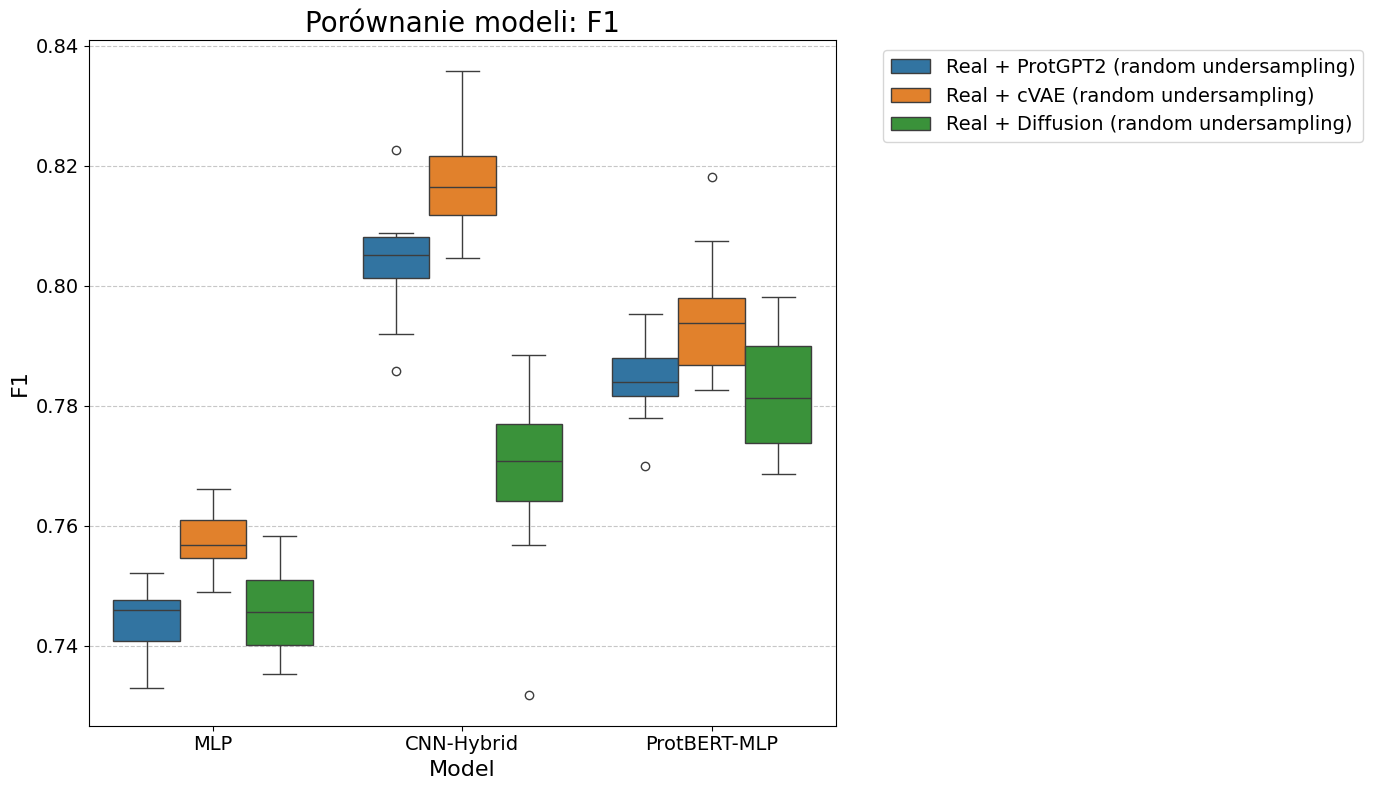

In [ ]:
plot_results(df_control_dl, "./files/plots/control_dl")

# Nemenyi test

In [ ]:
def run_nemenyi_analysis(df, model_name, metric='F1'):
    print(f"\n{'='*20} ANALIZA STATYSTYCZNA DLA MODELU: {model_name} (Metryka: {metric}) {'='*20}")

    df_model = df[df['Model'] == model_name].copy()

    try:
        df_pivot = df_model.pivot(index='Fold_ID', columns='Dataset', values=metric)
    except ValueError:
        df_model['Unique_Fold_ID'] = df_model.groupby(['Dataset']).cumcount()
        df_pivot = df_model.pivot(index='Unique_Fold_ID', columns='Dataset', values=metric)

    df_pivot = df_pivot.dropna()

    if df_pivot.empty:
        return None, None

    # 1. FRIEDMAN TEST
    data_groups = [df_pivot[col].values for col in df_pivot.columns]
    friedman_stat, friedman_p = stats.friedmanchisquare(*data_groups)

    print(f"Globalny test Friedmana: statystyka = {friedman_stat:.4f}, p-value = {friedman_p:.4e}")

    if friedman_p >= 0.05:
        return None, None

    # 2. NEMENYI POST-HOC
    nemenyi_matrix = sp.posthoc_nemenyi_friedman(df_pivot)

    return nemenyi_matrix, df_pivot

In [ ]:
df_baseline = pd.concat([df_stat, df_control_base], axis=0, ignore_index=True)

for model in df_baseline['Model'].unique():
    nemenyi_df_base_F1, pivot_df_base_F1 = run_nemenyi_analysis(df_baseline, model_name=model, metric='F1')

    if nemenyi_df_base_F1 is not None:
        nemenyi_df_base_F1.to_csv(f"./files/statistics_tests/nemenyi_{model}_F1.csv")
        display(nemenyi_df_base_F1)


==================== ANALIZA STATYSTYCZNA DLA MODELU: RandomForest (Metryka: F1) ====================
Globalny test Friedmana: statystyka = 40.6255, p-value = 5.8513e-06


,Real + Diffusion,Real + Diffusion (random undersampling),Real + Diffusion pLDDT > 70,Real + ProtGPT2,Real + ProtGPT2 (random undersampling),Real + ProtGPT2 pLDDT > 70,Real + cVAE,Real + cVAE (random undersampling),Real + cVAE pLDDT > 70,Real Only
Real + Diffusion,1.000,0.060,0.002,0.161,0.901,0.030,0.999,0.001,0.001,0.262
Real + Diffusion (random undersampling),0.060,1.000,0.994,1.000,0.836,1.000,0.348,0.963,0.975,1.000
Real + Diffusion pLDDT > 70,0.002,0.994,1.000,0.947,0.225,0.999,0.030,1.000,1.000,0.871
Real + ProtGPT2,0.161,1.000,0.947,1.000,0.963,1.000,0.603,0.836,0.871,1.000
Real + ProtGPT2 (random undersampling),0.901,0.836,0.225,0.963,1.000,0.705,0.999,0.111,0.134,0.990
Real + ProtGPT2 pLDDT > 70,0.030,1.000,0.999,1.000,0.705,1.000,0.225,0.990,0.994,0.998
Real + cVAE,0.999,0.348,0.030,0.603,0.999,0.225,1.000,0.011,0.014,0.753
Real + cVAE (random undersampling),0.001,0.963,1.000,0.836,0.111,0.990,0.011,1.000,1.000,0.705
Real + cVAE pLDDT > 70,0.001,0.975,1.000,0.871,0.134,0.994,0.014,1.000,1.000,0.753
Real Only,0.262,1.000,0.871,1.000,0.990,0.998,0.753,0.705,0.753,1.000



==================== ANALIZA STATYSTYCZNA DLA MODELU: XGBoost (Metryka: F1) ====================
Globalny test Friedmana: statystyka = 21.7091, p-value = 9.8481e-03


,Real + Diffusion,Real + Diffusion (random undersampling),Real + Diffusion pLDDT > 70,Real + ProtGPT2,Real + ProtGPT2 (random undersampling),Real + ProtGPT2 pLDDT > 70,Real + cVAE,Real + cVAE (random undersampling),Real + cVAE pLDDT > 70,Real Only
Real + Diffusion,1.000,0.990,0.048,0.947,0.134,0.161,0.963,0.019,0.348,0.753
Real + Diffusion (random undersampling),0.990,1.000,0.498,1.000,0.753,0.797,1.000,0.303,0.947,0.999
Real + Diffusion pLDDT > 70,0.048,0.498,1.000,0.705,1.000,1.000,0.655,1.000,0.998,0.927
Real + ProtGPT2,0.947,1.000,0.705,1.000,0.901,0.927,1.000,0.498,0.990,1.000
Real + ProtGPT2 (random undersampling),0.134,0.753,1.000,0.901,1.000,1.000,0.871,1.000,1.000,0.990
Real + ProtGPT2 pLDDT > 70,0.161,0.797,1.000,0.927,1.000,1.000,0.901,0.999,1.000,0.994
Real + cVAE,0.963,1.000,0.655,1.000,0.871,0.901,1.000,0.446,0.984,1.000
Real + cVAE (random undersampling),0.019,0.303,1.000,0.498,1.000,0.999,0.446,1.000,0.984,0.797
Real + cVAE pLDDT > 70,0.348,0.947,0.998,0.990,1.000,1.000,0.984,0.984,1.000,1.000
Real Only,0.753,0.999,0.927,1.000,0.990,0.994,1.000,0.797,1.000,1.000



==================== ANALIZA STATYSTYCZNA DLA MODELU: LogisticRegression (Metryka: F1) ====================
Globalny test Friedmana: statystyka = 85.1345, p-value = 1.5336e-14


,Real + Diffusion,Real + Diffusion (random undersampling),Real + Diffusion pLDDT > 70,Real + ProtGPT2,Real + ProtGPT2 (random undersampling),Real + ProtGPT2 pLDDT > 70,Real + cVAE,Real + cVAE (random undersampling),Real + cVAE pLDDT > 70,Real Only
Real + Diffusion,1.000,0.074,0.001,0.947,1.000,0.998,0.797,0.001,0.000,0.396
Real + Diffusion (random undersampling),0.074,1.000,0.963,0.001,0.038,0.446,0.947,0.947,0.603,0.999
Real + Diffusion pLDDT > 70,0.001,0.963,1.000,0.000,0.000,0.019,0.225,1.000,0.999,0.603
Real + ProtGPT2,0.947,0.001,0.000,1.000,0.984,0.498,0.074,0.000,0.000,0.011
Real + ProtGPT2 (random undersampling),1.000,0.038,0.000,0.984,1.000,0.990,0.655,0.000,0.000,0.262
Real + ProtGPT2 pLDDT > 70,0.998,0.446,0.019,0.498,0.990,1.000,0.997,0.014,0.001,0.901
Real + cVAE,0.797,0.947,0.225,0.074,0.655,0.997,1.000,0.191,0.030,1.000
Real + cVAE (random undersampling),0.001,0.947,1.000,0.000,0.000,0.014,0.191,1.000,1.000,0.550
Real + cVAE pLDDT > 70,0.000,0.603,0.999,0.000,0.000,0.001,0.030,1.000,1.000,0.161
Real Only,0.396,0.999,0.603,0.011,0.262,0.901,1.000,0.550,0.161,1.000


In [ ]:
for model in df_baseline['Model'].unique():
    nemenyi_df_base_MCC, pivot_df_base_MCC = run_nemenyi_analysis(df_baseline, model_name=model, metric='MCC')

    if nemenyi_df_base_MCC is not None:
        nemenyi_df_base_MCC.to_csv(f"./files/statistics_tests/nemenyi_{model}_MCC.csv")
        display(nemenyi_df_base_MCC)


==================== ANALIZA STATYSTYCZNA DLA MODELU: RandomForest (Metryka: MCC) ====================
Globalny test Friedmana: statystyka = 60.4800, p-value = 1.0834e-09


,Real + Diffusion,Real + Diffusion (random undersampling),Real + Diffusion pLDDT > 70,Real + ProtGPT2,Real + ProtGPT2 (random undersampling),Real + ProtGPT2 pLDDT > 70,Real + cVAE,Real + cVAE (random undersampling),Real + cVAE pLDDT > 70,Real Only
Real + Diffusion,1.000,0.191,0.000,0.550,0.014,0.003,1.000,0.014,0.011,0.000
Real + Diffusion (random undersampling),0.191,1.000,0.753,1.000,0.997,0.947,0.396,0.997,0.994,0.024
Real + Diffusion pLDDT > 70,0.000,0.753,1.000,0.348,0.997,1.000,0.002,0.997,0.998,0.836
Real + ProtGPT2,0.550,1.000,0.348,1.000,0.901,0.655,0.797,0.901,0.871,0.003
Real + ProtGPT2 (random undersampling),0.014,0.997,0.997,0.901,1.000,1.000,0.048,1.000,1.000,0.262
Real + ProtGPT2 pLDDT > 70,0.003,0.947,1.000,0.655,1.000,1.000,0.011,1.000,1.000,0.550
Real + cVAE,1.000,0.396,0.002,0.797,0.048,0.011,1.000,0.048,0.038,0.000
Real + cVAE (random undersampling),0.014,0.997,0.997,0.901,1.000,1.000,0.048,1.000,1.000,0.262
Real + cVAE pLDDT > 70,0.011,0.994,0.998,0.871,1.000,1.000,0.038,1.000,1.000,0.303
Real Only,0.000,0.024,0.836,0.003,0.262,0.550,0.000,0.262,0.303,1.000



==================== ANALIZA STATYSTYCZNA DLA MODELU: XGBoost (Metryka: MCC) ====================
Globalny test Friedmana: statystyka = 56.1818, p-value = 7.2460e-09


,Real + Diffusion,Real + Diffusion (random undersampling),Real + Diffusion pLDDT > 70,Real + ProtGPT2,Real + ProtGPT2 (random undersampling),Real + ProtGPT2 pLDDT > 70,Real + cVAE,Real + cVAE (random undersampling),Real + cVAE pLDDT > 70,Real Only
Real + Diffusion,1.000,0.836,0.191,0.975,0.001,0.002,0.990,0.048,0.603,0.000
Real + Diffusion (random undersampling),0.836,1.000,0.990,1.000,0.161,0.303,1.000,0.871,1.000,0.001
Real + Diffusion pLDDT > 70,0.191,0.990,1.000,0.901,0.797,0.927,0.836,1.000,1.000,0.060
Real + ProtGPT2,0.975,1.000,0.901,1.000,0.048,0.111,1.000,0.603,0.998,0.000
Real + ProtGPT2 (random undersampling),0.001,0.161,0.797,0.048,1.000,1.000,0.030,0.975,0.348,0.927
Real + ProtGPT2 pLDDT > 70,0.002,0.303,0.927,0.111,1.000,1.000,0.074,0.997,0.550,0.797
Real + cVAE,0.990,1.000,0.836,1.000,0.030,0.074,1.000,0.498,0.994,0.000
Real + cVAE (random undersampling),0.048,0.871,1.000,0.603,0.975,0.997,0.498,1.000,0.975,0.225
Real + cVAE pLDDT > 70,0.603,1.000,1.000,0.998,0.348,0.550,0.994,0.975,1.000,0.006
Real Only,0.000,0.001,0.060,0.000,0.927,0.797,0.000,0.225,0.006,1.000



==================== ANALIZA STATYSTYCZNA DLA MODELU: LogisticRegression (Metryka: MCC) ====================
Globalny test Friedmana: statystyka = 79.0036, p-value = 2.5485e-13


,Real + Diffusion,Real + Diffusion (random undersampling),Real + Diffusion pLDDT > 70,Real + ProtGPT2,Real + ProtGPT2 (random undersampling),Real + ProtGPT2 pLDDT > 70,Real + cVAE,Real + cVAE (random undersampling),Real + cVAE pLDDT > 70,Real Only
Real + Diffusion,1.000,0.111,0.002,0.836,1.000,1.000,1.000,0.008,0.000,0.225
Real + Diffusion (random undersampling),0.111,1.000,0.975,0.000,0.161,0.303,0.225,0.998,0.836,1.000
Real + Diffusion pLDDT > 70,0.002,0.975,1.000,0.000,0.004,0.011,0.006,1.000,1.000,0.901
Real + ProtGPT2,0.836,0.000,0.000,1.000,0.753,0.550,0.655,0.000,0.000,0.001
Real + ProtGPT2 (random undersampling),1.000,0.161,0.004,0.753,1.000,1.000,1.000,0.014,0.001,0.303
Real + ProtGPT2 pLDDT > 70,1.000,0.303,0.011,0.550,1.000,1.000,1.000,0.038,0.002,0.498
Real + cVAE,1.000,0.225,0.006,0.655,1.000,1.000,1.000,0.024,0.001,0.396
Real + cVAE (random undersampling),0.008,0.998,1.000,0.000,0.014,0.038,0.024,1.000,0.998,0.984
Real + cVAE pLDDT > 70,0.000,0.836,1.000,0.000,0.001,0.002,0.001,0.998,1.000,0.655
Real Only,0.225,1.000,0.901,0.001,0.303,0.498,0.396,0.984,0.655,1.000


In [ ]:
df_deep = pd.concat([df_stat_dl, df_stat_control_dl])

for model in df_deep['Model'].unique():
    nemenyi_df_deep_F1, pivot_df_deep_F1 = run_nemenyi_analysis(df_deep, model_name=model, metric='F1')

    if nemenyi_df_deep_F1 is not None:
        nemenyi_df_deep_F1.to_csv(f"./files/statistics_tests/nemenyi_{model}_F1.csv")
        display(nemenyi_df_deep_F1)


==================== ANALIZA STATYSTYCZNA DLA MODELU: MLP (Metryka: F1) ====================
Globalny test Friedmana: statystyka = 81.4909, p-value = 8.1673e-14


,Real + Diffusion,Real + Diffusion (random undersampling),Real + Diffusion pLDDT > 70,Real + ProtGPT2,Real + ProtGPT2 (random undersampling),Real + ProtGPT2 pLDDT > 70,Real + cVAE,Real + cVAE (random undersampling),Real + cVAE pLDDT > 70,Real Only
Real + Diffusion,1.000,0.060,0.024,0.975,0.074,0.498,1.000,0.000,0.000,1.000
Real + Diffusion (random undersampling),0.060,1.000,1.000,0.001,1.000,0.994,0.134,0.797,0.550,0.303
Real + Diffusion pLDDT > 70,0.024,1.000,1.000,0.000,1.000,0.963,0.060,0.927,0.753,0.161
Real + ProtGPT2,0.975,0.001,0.000,1.000,0.001,0.030,0.901,0.000,0.000,0.705
Real + ProtGPT2 (random undersampling),0.074,1.000,1.000,0.001,1.000,0.997,0.161,0.753,0.498,0.348
Real + ProtGPT2 pLDDT > 70,0.498,0.994,0.963,0.030,0.997,1.000,0.705,0.191,0.074,0.901
Real + cVAE,1.000,0.134,0.060,0.901,0.161,0.705,1.000,0.000,0.000,1.000
Real + cVAE (random undersampling),0.000,0.797,0.927,0.000,0.753,0.191,0.000,1.000,1.000,0.001
Real + cVAE pLDDT > 70,0.000,0.550,0.753,0.000,0.498,0.074,0.000,1.000,1.000,0.000
Real Only,1.000,0.303,0.161,0.705,0.348,0.901,1.000,0.001,0.000,1.000



==================== ANALIZA STATYSTYCZNA DLA MODELU: CNN-Hybrid (Metryka: F1) ====================
Globalny test Friedmana: statystyka = 59.0836, p-value = 2.0125e-09


,Real + Diffusion,Real + Diffusion (random undersampling),Real + Diffusion pLDDT > 70,Real + ProtGPT2,Real + ProtGPT2 (random undersampling),Real + ProtGPT2 pLDDT > 70,Real + cVAE,Real + cVAE (random undersampling),Real + cVAE pLDDT > 70,Real Only
Real + Diffusion,1.000,0.990,0.836,0.000,0.001,0.001,0.191,0.000,0.001,0.048
Real + Diffusion (random undersampling),0.990,1.000,1.000,0.003,0.060,0.030,0.836,0.000,0.038,0.498
Real + Diffusion pLDDT > 70,0.836,1.000,1.000,0.024,0.262,0.161,0.990,0.005,0.191,0.871
Real + ProtGPT2,0.000,0.003,0.024,1.000,0.997,1.000,0.348,1.000,0.999,0.705
Real + ProtGPT2 (random undersampling),0.001,0.060,0.262,0.997,1.000,1.000,0.901,0.947,1.000,0.994
Real + ProtGPT2 pLDDT > 70,0.001,0.030,0.161,1.000,1.000,1.000,0.797,0.984,1.000,0.975
Real + cVAE,0.191,0.836,0.990,0.348,0.901,0.797,1.000,0.134,0.836,1.000
Real + cVAE (random undersampling),0.000,0.000,0.005,1.000,0.947,0.984,0.134,1.000,0.975,0.396
Real + cVAE pLDDT > 70,0.001,0.038,0.191,0.999,1.000,1.000,0.836,0.975,1.000,0.984
Real Only,0.048,0.498,0.871,0.705,0.994,0.975,1.000,0.396,0.984,1.000



==================== ANALIZA STATYSTYCZNA DLA MODELU: ProtBERT-MLP (Metryka: F1) ====================
Globalny test Friedmana: statystyka = 63.7532, p-value = 2.5202e-10


,Real + Diffusion,Real + Diffusion (random undersampling),Real + Diffusion pLDDT > 70,Real + ProtGPT2,Real + ProtGPT2 (random undersampling),Real + ProtGPT2 pLDDT > 70,Real + cVAE,Real + cVAE (random undersampling),Real + cVAE pLDDT > 70,Real Only
Real + Diffusion,1.000,0.161,0.043,1.000,0.021,0.001,1.000,0.000,0.074,0.000
Real + Diffusion (random undersampling),0.161,1.000,1.000,0.060,1.000,0.836,0.396,0.705,1.000,0.797
Real + Diffusion pLDDT > 70,0.043,1.000,1.000,0.013,1.000,0.980,0.147,0.937,1.000,0.970
Real + ProtGPT2,1.000,0.060,0.013,1.000,0.006,0.000,0.998,0.000,0.024,0.000
Real + ProtGPT2 (random undersampling),0.021,1.000,1.000,0.006,1.000,0.996,0.082,0.980,1.000,0.993
Real + ProtGPT2 pLDDT > 70,0.001,0.836,0.980,0.000,0.996,1.000,0.004,1.000,0.947,1.000
Real + cVAE,1.000,0.396,0.147,0.998,0.082,0.004,1.000,0.001,0.225,0.003
Real + cVAE (random undersampling),0.000,0.705,0.937,0.000,0.980,1.000,0.001,1.000,0.871,1.000
Real + cVAE pLDDT > 70,0.074,1.000,1.000,0.024,1.000,0.947,0.225,0.871,1.000,0.927
Real Only,0.000,0.797,0.970,0.000,0.993,1.000,0.003,1.000,0.927,1.000


In [ ]:
df_deep = pd.concat([df_stat_dl, df_stat_control_dl])

for model in df_deep['Model'].unique():
    nemenyi_df_deep_MCC, pivot_df_deep_MCC = run_nemenyi_analysis(df_deep, model_name=model, metric='MCC')

    if nemenyi_df_deep_MCC is not None:
        nemenyi_df_deep_MCC.to_csv(f"./files/statistics_tests/nemenyi_{model}_F1.csv")
        display(nemenyi_df_deep_MCC)


==================== ANALIZA STATYSTYCZNA DLA MODELU: MLP (Metryka: MCC) ====================
Globalny test Friedmana: statystyka = 75.7964, p-value = 1.1001e-12


,Real + Diffusion,Real + Diffusion (random undersampling),Real + Diffusion pLDDT > 70,Real + ProtGPT2,Real + ProtGPT2 (random undersampling),Real + ProtGPT2 pLDDT > 70,Real + cVAE,Real + cVAE (random undersampling),Real + cVAE pLDDT > 70,Real Only
Real + Diffusion,1.000,0.262,0.191,0.994,0.074,0.396,1.000,0.000,0.000,0.008
Real + Diffusion (random undersampling),0.262,1.000,1.000,0.019,1.000,1.000,0.446,0.396,0.134,0.975
Real + Diffusion pLDDT > 70,0.191,1.000,1.000,0.011,1.000,1.000,0.348,0.498,0.191,0.990
Real + ProtGPT2,0.994,0.019,0.011,1.000,0.003,0.038,0.963,0.000,0.000,0.000
Real + ProtGPT2 (random undersampling),0.074,1.000,1.000,0.003,1.000,0.999,0.161,0.753,0.396,1.000
Real + ProtGPT2 pLDDT > 70,0.396,1.000,1.000,0.038,0.999,1.000,0.603,0.262,0.074,0.927
Real + cVAE,1.000,0.446,0.348,0.963,0.161,0.603,1.000,0.000,0.000,0.024
Real + cVAE (random undersampling),0.000,0.396,0.498,0.000,0.753,0.262,0.000,1.000,1.000,0.984
Real + cVAE pLDDT > 70,0.000,0.134,0.191,0.000,0.396,0.074,0.000,1.000,1.000,0.836
Real Only,0.008,0.975,0.990,0.000,1.000,0.927,0.024,0.984,0.836,1.000



==================== ANALIZA STATYSTYCZNA DLA MODELU: CNN-Hybrid (Metryka: MCC) ====================
Globalny test Friedmana: statystyka = 63.8618, p-value = 2.4008e-10


,Real + Diffusion,Real + Diffusion (random undersampling),Real + Diffusion pLDDT > 70,Real + ProtGPT2,Real + ProtGPT2 (random undersampling),Real + ProtGPT2 pLDDT > 70,Real + cVAE,Real + cVAE (random undersampling),Real + cVAE pLDDT > 70,Real Only
Real + Diffusion,1.000,0.963,0.753,0.000,0.000,0.000,0.603,0.000,0.005,0.000
Real + Diffusion (random undersampling),0.963,1.000,1.000,0.019,0.006,0.011,0.999,0.005,0.225,0.024
Real + Diffusion pLDDT > 70,0.753,1.000,1.000,0.091,0.038,0.060,1.000,0.030,0.550,0.111
Real + ProtGPT2,0.000,0.019,0.091,1.000,1.000,1.000,0.161,1.000,0.997,1.000
Real + ProtGPT2 (random undersampling),0.000,0.006,0.038,1.000,1.000,1.000,0.074,1.000,0.975,1.000
Real + ProtGPT2 pLDDT > 70,0.000,0.011,0.060,1.000,1.000,1.000,0.111,1.000,0.990,1.000
Real + cVAE,0.603,0.999,1.000,0.161,0.074,0.111,1.000,0.060,0.705,0.191
Real + cVAE (random undersampling),0.000,0.005,0.030,1.000,1.000,1.000,0.060,1.000,0.963,1.000
Real + cVAE pLDDT > 70,0.005,0.225,0.550,0.997,0.975,0.990,0.705,0.963,1.000,0.998
Real Only,0.000,0.024,0.111,1.000,1.000,1.000,0.191,1.000,0.998,1.000



==================== ANALIZA STATYSTYCZNA DLA MODELU: ProtBERT-MLP (Metryka: MCC) ====================
Globalny test Friedmana: statystyka = 65.9472, p-value = 9.4359e-11


,Real + Diffusion,Real + Diffusion (random undersampling),Real + Diffusion pLDDT > 70,Real + ProtGPT2,Real + ProtGPT2 (random undersampling),Real + ProtGPT2 pLDDT > 70,Real + cVAE,Real + cVAE (random undersampling),Real + cVAE pLDDT > 70,Real Only
Real + Diffusion,1.000,0.111,0.027,1.000,0.016,0.000,1.000,0.002,0.091,0.000
Real + Diffusion (random undersampling),0.111,1.000,1.000,0.074,1.000,0.871,0.262,0.975,1.000,0.396
Real + Diffusion pLDDT > 70,0.027,1.000,1.000,0.016,1.000,0.987,0.082,1.000,1.000,0.729
Real + ProtGPT2,1.000,0.074,0.016,1.000,0.010,0.000,1.000,0.001,0.060,0.000
Real + ProtGPT2 (random undersampling),0.016,1.000,1.000,0.010,1.000,0.996,0.054,1.000,1.000,0.817
Real + ProtGPT2 pLDDT > 70,0.000,0.871,0.987,0.000,0.996,1.000,0.002,1.000,0.901,0.999
Real + cVAE,1.000,0.262,0.082,1.000,0.054,0.002,1.000,0.008,0.225,0.000
Real + cVAE (random undersampling),0.002,0.975,1.000,0.001,1.000,1.000,0.008,1.000,0.984,0.984
Real + cVAE pLDDT > 70,0.091,1.000,1.000,0.060,1.000,0.901,0.225,0.984,1.000,0.446
Real Only,0.000,0.396,0.729,0.000,0.817,0.999,0.000,0.984,0.446,1.000


In [ ]:
if 'pivot_df_base_F1' in locals() and pivot_df_base_F1 is not None:
    ranks_df = pivot_df_base_F1.rank(axis=1, ascending=False)

    mean_ranks = ranks_df.mean().sort_values()

    mean_f1 = pivot_df_base_F1.mean().loc[mean_ranks.index]
    std_f1 = pivot_df_base_F1.std().loc[mean_ranks.index]

    ranking_table = pd.DataFrame({
        "Średnia Ranga (Miejsce)": mean_ranks,
        "Średnia wartość F1": mean_f1,
        "Odchylenie std F1": std_f1
    })

    print("="*25 + " RANKING MODELI KLASYCZNYCH (F1) " + "="*25)

    for i, (dataset_name, row) in enumerate(ranking_table.iterrows(), 1):
        print(f"{i}. {dataset_name}")
        print(f"   -> Średnia ranga: {row['Średnia Ranga (Miejsce)']:.2f}")
        print(f"   -> Średnie F1:    {row['Średnia wartość F1']:.4f} ± {row['Odchylenie std F1']:.4f}")
        print("-" * 50)

    ranking_table.to_csv("./files/statistics_tests/ranking_nemenyi_base_F1.csv")

========================= RANKING MODELI KLASYCZNYCH (F1) =========================
1. Real + cVAE pLDDT > 70
   -> Średnia ranga: 1.40
   -> Średnie F1:    0.7391 ± 0.0062
--------------------------------------------------
2. Real + cVAE (random undersampling)
   -> Średnia ranga: 2.30
   -> Średnie F1:    0.7343 ± 0.0061
--------------------------------------------------
3. Real + Diffusion pLDDT > 70
   -> Średnia ranga: 2.40
   -> Średnie F1:    0.7304 ± 0.0048
--------------------------------------------------
4. Real + Diffusion (random undersampling)
   -> Średnia ranga: 4.10
   -> Średnie F1:    0.7222 ± 0.0058
--------------------------------------------------
5. Real Only
   -> Średnia ranga: 5.10
   -> Średnie F1:    0.7153 ± 0.0061
--------------------------------------------------
6. Real + cVAE
   -> Średnia ranga: 5.90
   -> Średnie F1:    0.7099 ± 0.0054
--------------------------------------------------
7. Real + ProtGPT2 pLDDT > 70
   -> Średnia ranga: 7.10
   -> Śred

In [ ]:
if 'pivot_df_base_MCC' in locals() and pivot_df_base_MCC is not None:
    ranks_df = pivot_df_base_MCC.rank(axis=1, ascending=False)

    mean_ranks = ranks_df.mean().sort_values()

    mean_MCC = pivot_df_base_MCC.mean().loc[mean_ranks.index]
    std_MCC = pivot_df_base_MCC.std().loc[mean_ranks.index]

    ranking_table = pd.DataFrame({
        "Średnia Ranga (Miejsce)": mean_ranks,
        "Średnia wartość MCC": mean_MCC,
        "Odchylenie std MCC": std_MCC
    })

    print("="*25 + " RANKING MODELI KLASYCZNYCH (MCC) " + "="*25)

    for i, (dataset_name, row) in enumerate(ranking_table.iterrows(), 1):
        print(f"{i}. {dataset_name}")
        print(f"   -> Średnia ranga: {row['Średnia Ranga (Miejsce)']:.2f}")
        print(f"   -> Średnie MCC:    {row['Średnia wartość MCC']:.4f} ± {row['Odchylenie std MCC']:.4f}")
        print("-" * 50)

    ranking_table.to_csv("./files/statistics_tests/ranking_nemenyi_base_MCC.csv")

========================= RANKING MODELI KLASYCZNYCH (MCC) =========================
1. Real + cVAE pLDDT > 70
   -> Średnia ranga: 1.70
   -> Średnie MCC:    0.3963 ± 0.0149
--------------------------------------------------
2. Real + Diffusion pLDDT > 70
   -> Średnia ranga: 2.30
   -> Średnie MCC:    0.3918 ± 0.0086
--------------------------------------------------
3. Real + cVAE (random undersampling)
   -> Średnia ranga: 2.80
   -> Średnie MCC:    0.3874 ± 0.0144
--------------------------------------------------
4. Real + Diffusion (random undersampling)
   -> Średnia ranga: 3.90
   -> Średnie MCC:    0.3762 ± 0.0116
--------------------------------------------------
5. Real Only
   -> Średnia ranga: 4.30
   -> Średnie MCC:    0.3716 ± 0.0126
--------------------------------------------------
6. Real + ProtGPT2 pLDDT > 70
   -> Średnia ranga: 7.20
   -> Średnie MCC:    0.3390 ± 0.0197
--------------------------------------------------
7. Real + cVAE
   -> Średnia ranga: 7.40
   

In [ ]:
if 'pivot_df_deep_F1' in locals() and pivot_df_deep_F1 is not None:
    ranks_df = pivot_df_deep_F1.rank(axis=1, ascending=False)

    mean_ranks = ranks_df.mean().sort_values()

    mean_f1 = pivot_df_deep_F1.mean().loc[mean_ranks.index]
    std_f1 = pivot_df_deep_F1.std().loc[mean_ranks.index]

    ranking_table = pd.DataFrame({
        "Średnia Ranga (Miejsce)": mean_ranks,
        "Średnia wartość F1": mean_f1,
        "Odchylenie std F1": std_f1
    })

    print("="*25 + " RANKING MODELI GŁĘBOKICH (F1) " + "="*25)

    for i, (dataset_name, row) in enumerate(ranking_table.iterrows(), 1):
        print(f"{i}. {dataset_name}")
        print(f"   -> Średnia ranga: {row['Średnia Ranga (Miejsce)']:.2f}")
        print(f"   -> Średnie F1:    {row['Średnia wartość F1']:.4f} ± {row['Odchylenie std F1']:.4f}")
        print("-" * 50)

    ranking_table.to_csv("ranking_nemenyi_deep_F1.csv")

========================= RANKING MODELI GŁĘBOKICH (F1) =========================
1. Real + cVAE (random undersampling)
   -> Średnia ranga: 2.80
   -> Średnie F1:    0.7950 ± 0.0110
--------------------------------------------------
2. Real Only
   -> Średnia ranga: 3.00
   -> Średnie F1:    0.7918 ± 0.0130
--------------------------------------------------
3. Real + ProtGPT2 pLDDT > 70
   -> Średnia ranga: 3.10
   -> Średnie F1:    0.7910 ± 0.0060
--------------------------------------------------
4. Real + ProtGPT2 (random undersampling)
   -> Średnia ranga: 4.35
   -> Średnie F1:    0.7842 ± 0.0071
--------------------------------------------------
5. Real + Diffusion pLDDT > 70
   -> Średnia ranga: 4.65
   -> Średnie F1:    0.7860 ± 0.0095
--------------------------------------------------
6. Real + cVAE pLDDT > 70
   -> Średnia ranga: 4.90
   -> Średnie F1:    0.7846 ± 0.0101
--------------------------------------------------
7. Real + Diffusion (random undersampling)
   -> Średn

In [ ]:
if 'pivot_df_deep_MCC' in locals() and pivot_df_deep_MCC is not None:
    ranks_df = pivot_df_deep_MCC.rank(axis=1, ascending=False)

    mean_ranks = ranks_df.mean().sort_values()

    mean_MCC = pivot_df_deep_MCC.mean().loc[mean_ranks.index]
    std_MCC = pivot_df_deep_MCC.std().loc[mean_ranks.index]

    ranking_table = pd.DataFrame({
        "Średnia Ranga (Miejsce)": mean_ranks,
        "Średnia wartość MCC": mean_MCC,
        "Odchylenie std MCC": std_MCC
    })

    print("="*25 + " RANKING MODELI GŁĘBOKICH (MCC) " + "="*25)

    for i, (dataset_name, row) in enumerate(ranking_table.iterrows(), 1):
        print(f"{i}. {dataset_name}")
        print(f"   -> Średnia ranga: {row['Średnia Ranga (Miejsce)']:.2f}")
        print(f"   -> Średnie MCC:    {row['Średnia wartość MCC']:.4f} ± {row['Odchylenie std MCC']:.4f}")
        print("-" * 50)

    ranking_table.to_csv("./files/statistics_tests/ranking_nemenyi_deep_MCC.csv")

========================= RANKING MODELI GŁĘBOKICH (MCC) =========================
1. Real Only
   -> Średnia ranga: 2.10
   -> Średnie MCC:    0.5546 ± 0.0198
--------------------------------------------------
2. Real + ProtGPT2 pLDDT > 70
   -> Średnia ranga: 3.10
   -> Średnie MCC:    0.5418 ± 0.0174
--------------------------------------------------
3. Real + cVAE (random undersampling)
   -> Średnia ranga: 3.60
   -> Średnie MCC:    0.5500 ± 0.0342
--------------------------------------------------
4. Real + ProtGPT2 (random undersampling)
   -> Średnia ranga: 4.35
   -> Średnie MCC:    0.5232 ± 0.0182
--------------------------------------------------
5. Real + Diffusion pLDDT > 70
   -> Średnia ranga: 4.55
   -> Średnie MCC:    0.5254 ± 0.0245
--------------------------------------------------
6. Real + cVAE pLDDT > 70
   -> Średnia ranga: 5.10
   -> Średnie MCC:    0.5209 ± 0.0321
--------------------------------------------------
7. Real + Diffusion (random undersampling)
   -